# Split-Based Comparison: Finetuned vs Baseline Beat This vs madmom

## Why This Notebook Exists
This notebook compares model performance on the **same held-out test split** to avoid train-test leakage and optimistic bias.

## Train / Validation / Test Protocol Used
The dataset was split once (seeded random split) into:
- **Train (70%)**: used to fit model parameters.
- **Validation (15%)**: used for model selection / early stopping during training.
- **Test (15%)**: never used for optimization; used only once for final reporting.

For fairness, baseline Beat This and madmom are filtered to the **exact same test `track_id` set** as the finetuned run.

## What You’ll See
- Aggregate metric comparisons (beat and downbeat)
- Per-track deltas (improvement/regression)
- Best/worst tracks by model
- Overlap analysis of difficult tracks
- Head-to-head win rates and diagnostic plots


## 1) Data Loading and Alignment

This step loads all three CSVs and restricts analysis to the **strict track intersection** so every model is scored on identical examples.

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

EVAL_DIR = Path('csvs')
IMG_DIR = Path('img')
IMG_DIR.mkdir(exist_ok=True)

FT_CSV = EVAL_DIR / 'beat_this_jtd_finetuned_test701515.csv'
BT_CSV = EVAL_DIR / 'beat_this_jtd.csv'
MM_CSV = EVAL_DIR / 'madmom_jtd.csv'

assert FT_CSV.exists(), f'Missing: {FT_CSV}'
assert BT_CSV.exists(), f'Missing: {BT_CSV}'
assert MM_CSV.exists(), f'Missing: {MM_CSV}'

ft = pd.read_csv(FT_CSV)
bt = pd.read_csv(BT_CSV)
mm = pd.read_csv(MM_CSV)

# use only tracks in split-based finetuned test CSV
split_ids = set(ft['track_id'].astype(str))

bt = bt[bt['track_id'].astype(str).isin(split_ids)].copy()
mm = mm[mm['track_id'].astype(str).isin(split_ids)].copy()

print('Rows:')
print('  Finetuned:', len(ft))
print('  Beat This baseline (filtered):', len(bt))
print('  madmom (filtered):', len(mm))

common = split_ids & set(bt['track_id'].astype(str)) & set(mm['track_id'].astype(str))
print('  Common across all three:', len(common))

# keep strict intersection for fair pairwise comparison
ft = ft[ft['track_id'].astype(str).isin(common)].copy()
bt = bt[bt['track_id'].astype(str).isin(common)].copy()
mm = mm[mm['track_id'].astype(str).isin(common)].copy()

print('Using strict intersection rows:', len(ft))

Rows:
  Finetuned: 194
  Beat This baseline (filtered): 194
  madmom (filtered): 194
  Common across all three: 194
Using strict intersection rows: 194


## 2) Aggregate Metrics Table

These are macro means across the aligned test tracks. This is the primary table for high-level comparison.

In [23]:
metrics = [
    'beat_F-measure', 'beat_CMLt', 'beat_AMLt', 'beat_Cemgil',
    'downbeat_F-measure', 'downbeat_CMLt', 'downbeat_AMLt', 'downbeat_Cemgil'
]

def summarize(df, name):
    s = {m: pd.to_numeric(df[m], errors='coerce').mean() for m in metrics}
    s['model'] = name
    return s

summary = pd.DataFrame([
    summarize(ft, 'Beat This finetuned'),
    summarize(bt, 'Beat This baseline'),
    summarize(mm, 'madmom'),
]).set_index('model')

summary.round(4)

,beat_F-measure,beat_CMLt,beat_AMLt,beat_Cemgil,downbeat_F-measure,downbeat_CMLt,downbeat_AMLt,downbeat_Cemgil
model,,,,,,,,
Beat This finetuned,0.9751,0.9515,0.9618,0.9288,0.5999,0.2428,0.3282,0.5734
Beat This baseline,0.9432,0.8453,0.8972,0.8868,0.6189,0.5430,0.6284,0.5880
madmom,0.8702,0.6499,0.9263,0.8563,0.6497,0.5474,0.8440,0.6401


## 3) Delta vs Baselines

Positive deltas mean finetuning improved over the comparison model; negative deltas indicate regressions.

In [24]:
delta_vs_bt = summary.loc['Beat This finetuned'] - summary.loc['Beat This baseline']
delta_vs_mm = summary.loc['Beat This finetuned'] - summary.loc['madmom']

print('Delta (finetuned - baseline Beat This):')
display(delta_vs_bt.to_frame('delta').round(4))

print('Delta (finetuned - madmom):')
display(delta_vs_mm.to_frame('delta').round(4))

Delta (finetuned - baseline Beat This):


,delta
beat_F-measure,0.0319
beat_CMLt,0.1062
beat_AMLt,0.0646
beat_Cemgil,0.0421
downbeat_F-measure,-0.0191
downbeat_CMLt,-0.3002
downbeat_AMLt,-0.3002
downbeat_Cemgil,-0.0146


Delta (finetuned - madmom):


,delta
beat_F-measure,0.1049
beat_CMLt,0.3016
beat_AMLt,0.0355
beat_Cemgil,0.0725
downbeat_F-measure,-0.0499
downbeat_CMLt,-0.3046
downbeat_AMLt,-0.5158
downbeat_Cemgil,-0.0667


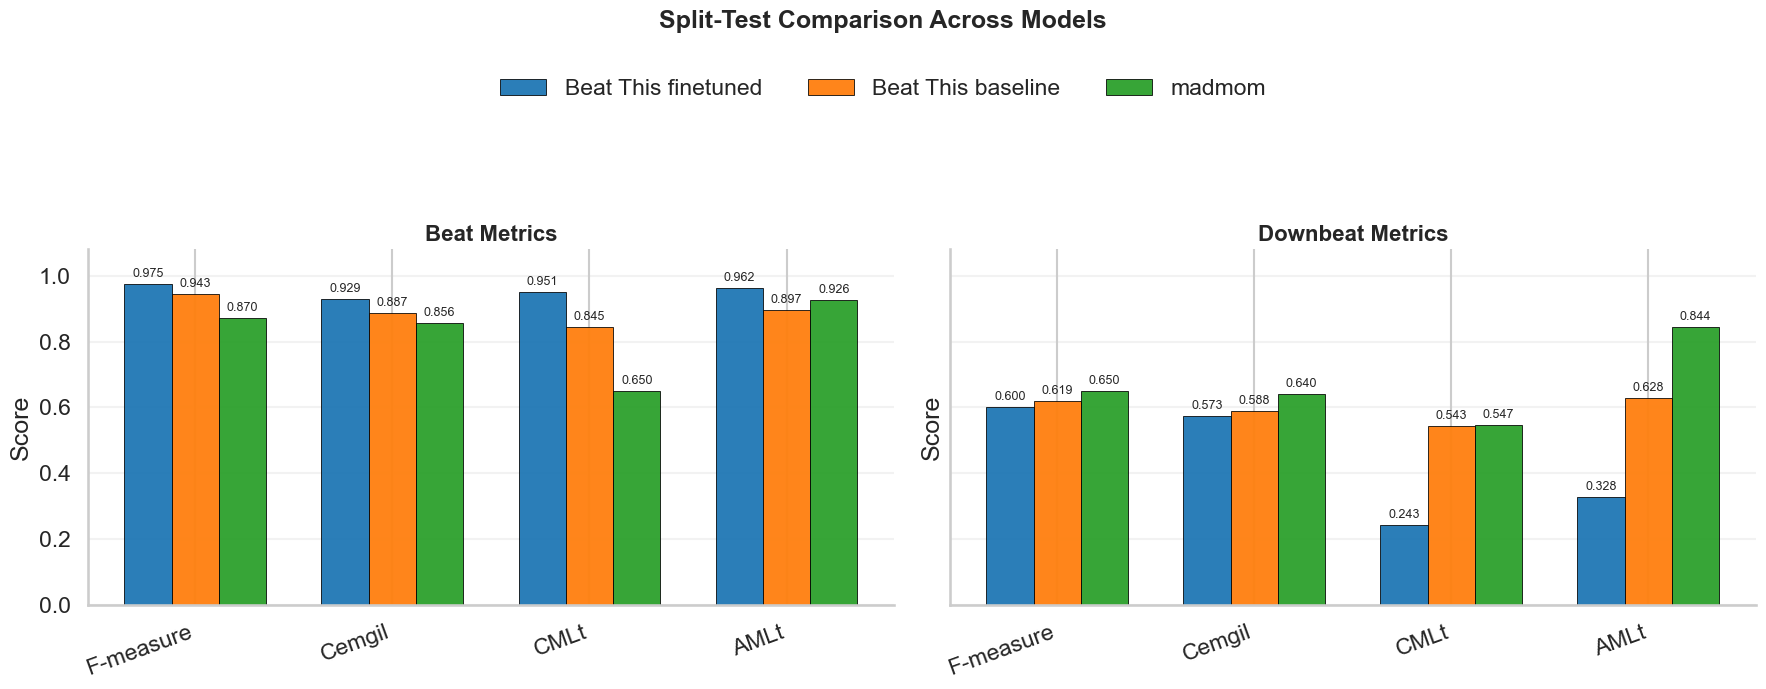

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

candidate_metrics = ['F-measure', 'Cemgil', 'P-score', 'CMLt', 'AMLt', 'Information gain']
model_order = ['Beat This finetuned', 'Beat This baseline', 'madmom']
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

def plot_available_metric_bars(ax, prefix):
    available = [m for m in candidate_metrics if f'{prefix}_{m}' in summary.columns]
    cols = [f'{prefix}_{m}' for m in available]
    plot_df = summary.loc[model_order, cols].copy()
    plot_df.columns = available

    x = np.arange(len(available))
    width = 0.24

    for j, model in enumerate(model_order):
        vals = plot_df.loc[model].values
        bars = ax.bar(
            x + (j - 1) * width,
            vals,
            width=width,
            label=model,
            color=model_colors[j],
            edgecolor='black',
            linewidth=0.6,
            alpha=0.95,
        )

        # label all bars
        for b, v in zip(bars, vals):
            ax.text(
                b.get_x() + b.get_width() / 2,
                b.get_height() + 0.012,
                f"{v:.3f}",
                ha='center',
                va='bottom',
                fontsize=9,
            )

    ax.set_title(f"{prefix.capitalize()} Metrics", fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available, rotation=20, ha='right')
    ax.set_ylim(0, 1.08)  # extra room for labels
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return ax.get_legend_handles_labels()

# Combined chart: beat and downbeat stacked vertically.
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharey=True)
legend_handles, legend_labels = None, None
for ax, prefix in zip(axes, ['beat', 'downbeat']):
    legend_handles, legend_labels = plot_available_metric_bars(ax, prefix)

fig.legend(legend_handles, legend_labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Split-Test Comparison Across Models", fontsize=18, fontweight='bold', y=1.06)
plt.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(IMG_DIR / 'split_comparison_metric_bars_available.png', dpi=300, bbox_inches='tight')
plt.show()

# Separate charts for report use.
for prefix in ['beat', 'downbeat']:
    fig, ax = plt.subplots(figsize=(14, 6))
    handles, labels = plot_available_metric_bars(ax, prefix)
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.04))
    fig.suptitle(f"Split-Test Comparison Across Models: {prefix.capitalize()}", fontsize=18, fontweight='bold', y=1.10)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(IMG_DIR / f'split_comparison_metric_bars_available_{prefix}.png', dpi=300, bbox_inches='tight')
    plt.show()

## 5) Distribution View (F-measure)

Boxplots show spread/variance, not just means, for beat and downbeat F-measure.

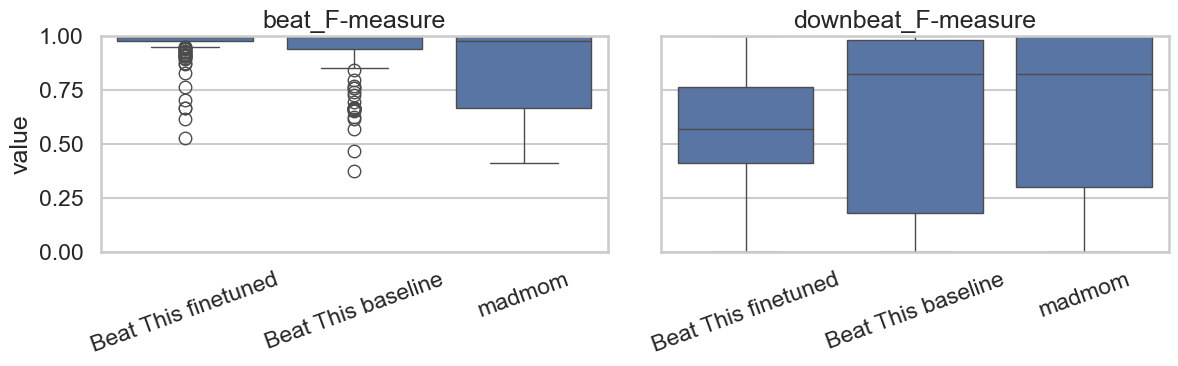

In [26]:
# Distribution comparison for headline metrics
long_rows = []
for name, df in [('Beat This finetuned', ft), ('Beat This baseline', bt), ('madmom', mm)]:
    for metric in ['beat_F-measure', 'downbeat_F-measure']:
        vals = pd.to_numeric(df[metric], errors='coerce').dropna()
        for v in vals:
            long_rows.append({'model': name, 'metric': metric, 'value': v})

long_df = pd.DataFrame(long_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, metric in zip(axes, ['beat_F-measure', 'downbeat_F-measure']):
    sns.boxplot(data=long_df[long_df['metric'] == metric], x='model', y='value', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(IMG_DIR / 'split_comparison_f_measure_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## Track-Level Diagnostics
These sections identify best/worst tracks, model overlap on failures, and where finetuning helps or hurts most.

## 6) Track-Level Diagnostics Setup

Prepare per-track joined table to analyze where finetuning helps most, where it hurts, and failure overlap.

In [27]:
# Build aligned per-track table for direct model-vs-model comparisons
key_cols = ['track_id', 'beat_F-measure', 'downbeat_F-measure', 'beat_Cemgil', 'downbeat_Cemgil']

ft_k = ft[key_cols].rename(columns={c: f'ft_{c}' for c in key_cols if c != 'track_id'})
bt_k = bt[key_cols].rename(columns={c: f'bt_{c}' for c in key_cols if c != 'track_id'})
mm_k = mm[key_cols].rename(columns={c: f'mm_{c}' for c in key_cols if c != 'track_id'})

cmp = ft_k.merge(bt_k, on='track_id', how='inner').merge(mm_k, on='track_id', how='inner')

# deltas
for m in ['beat_F-measure', 'downbeat_F-measure', 'beat_Cemgil', 'downbeat_Cemgil']:
    cmp[f'delta_ft_minus_bt_{m}'] = cmp[f'ft_{m}'] - cmp[f'bt_{m}']
    cmp[f'delta_ft_minus_mm_{m}'] = cmp[f'ft_{m}'] - cmp[f'mm_{m}']

print('Aligned rows:', len(cmp))
cmp.head()

Aligned rows: 194


,track_id,ft_beat_F-measure,ft_downbeat_F-measure,ft_beat_Cemgil,ft_downbeat_Cemgil,bt_beat_F-measure,bt_downbeat_F-measure,bt_beat_Cemgil,bt_downbeat_Cemgil,mm_beat_F-measure,...,mm_beat_Cemgil,mm_downbeat_Cemgil,delta_ft_minus_bt_beat_F-measure,delta_ft_minus_mm_beat_F-measure,delta_ft_minus_bt_downbeat_F-measure,delta_ft_minus_mm_downbeat_F-measure,delta_ft_minus_bt_beat_Cemgil,delta_ft_minus_mm_beat_Cemgil,delta_ft_minus_bt_downbeat_Cemgil,delta_ft_minus_mm_downbeat_Cemgil
0,barronk-bouncinwithbud-carterrcobhamb-2003-543...,0.983210,0.597064,0.940740,0.568061,0.981818,0.847880,0.935832,0.809167,0.657706,...,0.638524,0.597548,0.001392,0.325504,-0.250817,-0.012255,0.004908,0.302215,-0.241106,-0.029487
1,barronk-outofnowhere-carterrcobhamb-2003-5ef86b93,0.977839,0.951351,0.926418,0.908872,0.983333,0.988889,0.931734,0.931917,0.981969,...,0.958566,0.676779,-0.005494,-0.004130,-0.037538,0.262462,-0.005317,-0.032149,-0.023045,0.232093
2,barronk-surreywiththefringeon-drummondrrileyb-...,0.998172,0.432000,0.970409,0.421981,0.999085,0.000000,0.937345,0.000001,0.660147,...,0.653001,0.423847,-0.000913,0.338025,0.432000,0.000627,0.033064,0.317408,0.421980,-0.001865
3,barronk-theonlyone-drummondrrileyb-1996-2d0f261a,0.989526,0.868571,0.960947,0.844638,0.962090,0.895464,0.926320,0.864938,0.989526,...,0.977874,0.897434,0.027436,0.000000,-0.026892,-0.039795,0.034626,-0.016927,-0.020301,-0.052796
4,barronk-thereisnogreaterlove-williamsbrileyb-1...,0.872622,0.474295,0.799591,0.450647,0.874279,0.494226,0.784315,0.465981,0.829268,...,0.776093,0.620222,-0.001657,0.043354,-0.019931,-0.167309,0.015276,0.023498,-0.015335,-0.169575


## 7) Best and Worst Tracks per Model

Lists top and bottom tracks for each model separately on beat and downbeat F-measure.

In [28]:
# Best/worst tracks for each model on beat/downbeat F
def top_bottom(df, model_prefix, metric='beat_F-measure', n=10):
    col = f'{model_prefix}_{metric}'
    best = df[['track_id', col]].sort_values(col, ascending=False).head(n).reset_index(drop=True)
    worst = df[['track_id', col]].sort_values(col, ascending=True).head(n).reset_index(drop=True)
    return best, worst

for prefix, name in [('ft', 'Finetuned'), ('bt', 'Baseline Beat This'), ('mm', 'madmom')]:
    print(f'\n=== {name} : beat_F-measure ===')
    best, worst = top_bottom(cmp, prefix, 'beat_F-measure', n=10)
    print('Best:')
    display(best)
    print('Worst:')
    display(worst)

for prefix, name in [('ft', 'Finetuned'), ('bt', 'Baseline Beat This'), ('mm', 'madmom')]:
    print(f'\n=== {name} : downbeat_F-measure ===')
    best, worst = top_bottom(cmp, prefix, 'downbeat_F-measure', n=10)
    print('Best:')
    display(best)
    print('Worst:')
    display(worst)


=== Finetuned : beat_F-measure ===
Best:


,track_id,ft_beat_F-measure
0,jamala-likesomeoneinlove-nasserjfournierv-1966...,1.0
1,evansb-whocares-israelscbunkerl-1961-7ffcaefd,1.0
2,garlandr-everytimeifeelthespirit-jonesstaylora...,1.0
3,nicholsh-applejackinalternate-mckibbonaroachm-...,1.0
4,flanagant-tintindeo-washingtonpnashl-1997-2177...,1.0
5,flanagant-outofthepast-mrazgfostera-1986-db84afdc,1.0
6,flanagant-justfriends-tuckerbbaileyd-1961-0469...,1.0
7,nicholsh-brassringsalternate-mckibbonablakeya-...,1.0
8,flanagant-asleepinbee-mrazgkayc-1977-4f87e31b,1.0
9,nicholsh-crispday-mckibbonablakeya-1957-8d73db7a,1.0


Worst:


,track_id,ft_beat_F-measure
0,tynerm-darnthatdream-sharpeascotta-1989-6cc187a8,0.530769
1,jarrettk-ithoughtaboutyou-peacockgdejohnettej-...,0.619048
2,monkt-aprilinparis-rameygblakeya-1949-c50b1c36,0.666667
3,brownr-myheartstoodstill-smithpbellsonl-1978-d...,0.666667
4,bleyp-syndrome-swallowslap-1963-e13458a9,0.707483
5,jamala-yougotomyhead-crosbyifournierv-1960-5a0...,0.764007
6,coreac-sophisticatedlady-patituccijweckld-1989...,0.831510
7,barronk-thereisnogreaterlove-williamsbrileyb-1...,0.872622
8,jarrettk-lisbonstomp-hadencmotianp-1968-8994c848,0.878254
9,jamala-angeleyes-crosbyifournierv-1961-69a58683,0.894737



=== Baseline Beat This : beat_F-measure ===
Best:


...

,track_id,bt_downbeat_F-measure
0,jamala-darnthatdream-crosbyifournierv-1959-0ab...,0.0
1,powellb-saltpeanuts-duviviergtaylora-1956-4aca...,0.0
2,kellyw-anotherblues-chamberspcobbj-1965-72c37dbf,0.0
3,kellyw-dontchahearmecallin-mcclurercobbj-1966-...,0.0
4,kellyw-onacleardayyou-mcclurercobbj-1966-b01f94af,0.0
5,petersono-iloveyou-brownrthigpene-1961-5c99390e,0.0
6,petersono-hallelujahtrail-orstednhannaj-1974-4...,0.0
7,evansb-perisscope-lafarosmotianp-1961-1d09ff52,0.0
8,tristanol-movinalong-indplevitta-1956-29226550,0.0
9,powellb-bluesinthecloset-pettifordoclarkek-196...,0.0



=== madmom : downbeat_F-measure ===
Best:


,track_id,mm_downbeat_F-measure
0,jamala-likesomeoneinlove-nasserjfournierv-1966...,1.0
1,hollandd-yesterdays-joneshhigginsb-1989-126bab92,1.0
2,jonesh-reunion-hintonmrosengardenb-1977-9b2ec5e0,1.0
3,jonesh-nowsthetime-eckingeribongk-1977-52c8d96b,1.0
4,jonesh-flymetothemoon-wongdpearsonl-2010-ce7f21e1,1.0
5,jonesh-confirmation-duviviergrileyb-1977-68b64fa3,1.0
6,jarrettk-wrapyourtroublesindreams-peacockgdejo...,1.0
7,jarrettk-four-peacockgdejohnettej-2002-98340dc4,1.0
8,jarrettk-bouncingwithbud-peacockgdejohnettej-1...,1.0
9,jamala-youremyeverything-nasserjgantf-1970-617...,1.0


Worst:


,track_id,mm_downbeat_F-measure
0,jamala-darnthatdream-crosbyifournierv-1959-0ab...,0.0
1,drewk-bemylove-russellcblakeya-1951-15d2c22f,0.0
2,nicholsh-query-koticktroachm-1955-7d101c19,0.0
3,nicholsh-furthermorealternate-mckibbonaroachm-...,0.0
4,nicholsh-crispday-mckibbonablakeya-1957-8d73db7a,0.0
5,monkt-evidence-mckibbonablakeya-1971-3d0e983e,0.0
6,mancej-thejumpinblues-cranshawbrokerm-1963-125...,0.0
7,mancej-softlyasinamorning-woodejdurhamb-1994-a...,0.0
8,mancej-goodbait-thompsondalleynea-1997-d4b26a19,0.0
9,evansb-makesomeonehappy-israelscbunkerl-1966-6...,0.0


## 8) Overlap of Difficult Tracks

Compares worst-decile sets to see which failures are shared across models vs model-specific.

In [29]:
# Overlap of difficult tracks (worst decile)
def worst_set(df, col, q=0.10):
    thresh = df[col].quantile(q)
    return set(df.loc[df[col] <= thresh, 'track_id']), thresh

sets = {}
for prefix in ['ft', 'bt', 'mm']:
    s, t = worst_set(cmp, f'{prefix}_beat_F-measure', q=0.10)
    sets[prefix] = s
    print(prefix, 'beat worst10% threshold:', round(t, 3), 'count:', len(s))

print('\nBeat worst-set overlaps:')
print('ft ∩ bt:', len(sets['ft'] & sets['bt']))
print('ft ∩ mm:', len(sets['ft'] & sets['mm']))
print('bt ∩ mm:', len(sets['bt'] & sets['mm']))
print('all three:', len(sets['ft'] & sets['bt'] & sets['mm']))

sets_db = {}
for prefix in ['ft', 'bt', 'mm']:
    s, t = worst_set(cmp, f'{prefix}_downbeat_F-measure', q=0.10)
    sets_db[prefix] = s
    print(prefix, 'downbeat worst10% threshold:', round(t, 3), 'count:', len(s))

print('\nDownbeat worst-set overlaps:')
print('ft ∩ bt:', len(sets_db['ft'] & sets_db['bt']))
print('ft ∩ mm:', len(sets_db['ft'] & sets_db['mm']))
print('bt ∩ mm:', len(sets_db['bt'] & sets_db['mm']))
print('all three:', len(sets_db['ft'] & sets_db['bt'] & sets_db['mm']))

ft beat worst10% threshold: 0.929 count: 20
bt beat worst10% threshold: 0.811 count: 20
mm beat worst10% threshold: 0.66 count: 20

Beat worst-set overlaps:
ft ∩ bt: 11
ft ∩ mm: 3
bt ∩ mm: 4
all three: 3
ft downbeat worst10% threshold: 0.35 count: 20
bt downbeat worst10% threshold: 0.0 count: 26
mm downbeat worst10% threshold: 0.0 count: 33

Downbeat worst-set overlaps:
ft ∩ bt: 11
ft ∩ mm: 7
bt ∩ mm: 9
all three: 6


## 9) Head-to-Head Win Rates

Counts per-track wins/losses (ignoring ties) for finetuned vs each baseline.

In [30]:
# Head-to-head win rates (strict >, ties ignored)
def win_rate(a, b):
    gt = (a > b).sum()
    lt = (a < b).sum()
    ties = (a == b).sum()
    denom = gt + lt
    wr = (gt / denom) if denom else float('nan')
    return gt, lt, ties, wr

for metric in ['beat_F-measure', 'downbeat_F-measure', 'beat_Cemgil', 'downbeat_Cemgil']:
    print(f'\nMetric: {metric}')
    for other, label in [('bt', 'baseline Beat This'), ('mm', 'madmom')]:
        gt, lt, ties, wr = win_rate(cmp[f'ft_{metric}'], cmp[f'{other}_{metric}'])
        print(f'finetuned vs {label}: wins={gt}, losses={lt}, ties={ties}, win_rate={wr:.3f}')


Metric: beat_F-measure
finetuned vs baseline Beat This: wins=79, losses=16, ties=99, win_rate=0.832
finetuned vs madmom: wins=84, losses=33, ties=77, win_rate=0.718

Metric: downbeat_F-measure
finetuned vs baseline Beat This: wins=77, losses=106, ties=11, win_rate=0.421
finetuned vs madmom: wins=69, losses=118, ties=7, win_rate=0.369

Metric: beat_Cemgil
finetuned vs baseline Beat This: wins=156, losses=38, ties=0, win_rate=0.804
finetuned vs madmom: wins=69, losses=125, ties=0, win_rate=0.356

Metric: downbeat_Cemgil
finetuned vs baseline Beat This: wins=89, losses=105, ties=0, win_rate=0.459
finetuned vs madmom: wins=68, losses=126, ties=0, win_rate=0.351


## 10) Largest Improvements and Regressions

Highlights individual tracks with biggest positive/negative deltas from finetuning.

In [31]:
# Largest improvements/regressions for finetuned vs baseline Beat This
for metric in ['beat_F-measure', 'downbeat_F-measure']:
    dcol = f'delta_ft_minus_bt_{metric}'
    print(f'\nTop improvements ({metric})')
    display(cmp[['track_id', dcol]].sort_values(dcol, ascending=False).head(15).reset_index(drop=True))

    print(f'Top regressions ({metric})')
    display(cmp[['track_id', dcol]].sort_values(dcol, ascending=True).head(15).reset_index(drop=True))


Top improvements (beat_F-measure)


,track_id,delta_ft_minus_bt_beat_F-measure
0,powellb-saltpeanuts-duviviergtaylora-1956-4aca...,0.337838
1,petersono-woodynyou-brownrthigpene-1961-f34313d2,0.334228
2,tynerm-thewiseone-sharpeascotta-1991-a8ff2e12,0.324003
3,timmonsb-walkinwadinsittinridin-jonesslucasr-1...,0.322561
4,evansb-ttttwelvetonetune-gomezemorellm-1971-36...,0.305164
5,jonesh-likesomeoneinlove-duviviergjacksono-197...,0.300633
6,coreac-sophisticatedlady-patituccijweckld-1989...,0.260873
7,hicksj-daydream-dolphindbrooksc-1997-a1b552e8,0.257666
8,brownr-mightycoolpenthouse-joneshthigpene-1956...,0.256698
9,jarrettk-ithoughtaboutyou-peacockgdejohnettej-...,0.244048


Top regressions (beat_F-measure)


,track_id,delta_ft_minus_bt_beat_F-measure
0,evansb-myromance-johnsonmlabarberaj-1980-0ac208d7,-0.022664
1,bleyp-blueswaltz-lundgaardjhartb-1985-e7d9851f,-0.020173
2,garlandr-solar-carterrjoep-1977-a821803c,-0.018868
3,evansb-turnoutthestars-gomezedejohnettej-1967-...,-0.010675
4,petersono-wheatland-orstednhayesl-1971-94f2480f,-0.007168
5,evansb-swedishpastry-israelscbunkerl-1963-3601...,-0.005721
6,kellyw-dontchahearmecallin-mcclurercobbj-1966-...,-0.005698
7,barronk-outofnowhere-carterrcobhamb-2003-5ef86b93,-0.005494
8,brownr-myromance-moronidnashl-1994-21fb6b42,-0.003774
9,brownr-youremyeverything-greenbhutchinsong-199...,-0.002203



Top improvements (downbeat_F-measure)


,track_id,delta_ft_minus_bt_downbeat_F-measure
0,monkt-aprilinparis-rameygblakeya-1949-c50b1c36,0.650000
1,petersono-hallelujahtrail-orstednhannaj-1974-4...,0.515152
2,mancej-taketheatrain-cleyndertabrowns-2000-fae...,0.507082
3,powellb-move-orstednschiopffew-1962-4adcfdea,0.470602
4,jamala-darnthatdream-crosbyifournierv-1959-0ab...,0.453608
5,petersono-woodynyou-brownrthigpene-1961-f34313d2,0.438928
6,clarks-cantwebefriends-chambersplandersw-1958-...,0.435744
7,barronk-surreywiththefringeon-drummondrrileyb-...,0.432000
8,waltonc-banda-carterrdejohnettej-1983-c91a7eaf,0.422360
9,evansb-perisscope-gomezemorellm-1973-0e6c1811,0.415686


Top regressions (downbeat_F-measure)


,track_id,delta_ft_minus_bt_downbeat_F-measure
0,jonesh-opusdefunk-wongdpearsonl-2010-a8c956eb,-0.574194
1,evansb-turnoutthestars-gomezedejohnettej-1967-...,-0.528768
2,petersono-wheatland-orstednhayesl-1971-94f2480f,-0.502564
3,evansb-howdeepistheocean-gomezemorellm-1969-29...,-0.486188
4,petersono-whendidifallin-brownrthigpene-1960-d...,-0.481813
5,tynerm-thewiseone-sharpeascotta-1991-a8ff2e12,-0.479295
6,jamala-poorbutterfly-crosbyifournierv-1958-94f...,-0.475728
7,timmonsb-datdere-carterrtootiea-1961-9dbec53a,-0.473341
8,clarks-bluesmambo-duviviergroachm-1959-2170b9c0,-0.457930
9,ibrahima-honey-gertzejntshokom-1965-7318553e,-0.453791


## 11) Diagnostic Plots for Deltas and Agreement

- Delta histograms: distribution of finetuned-minus-baseline changes
- Scatter plots: baseline vs finetuned score agreement by track

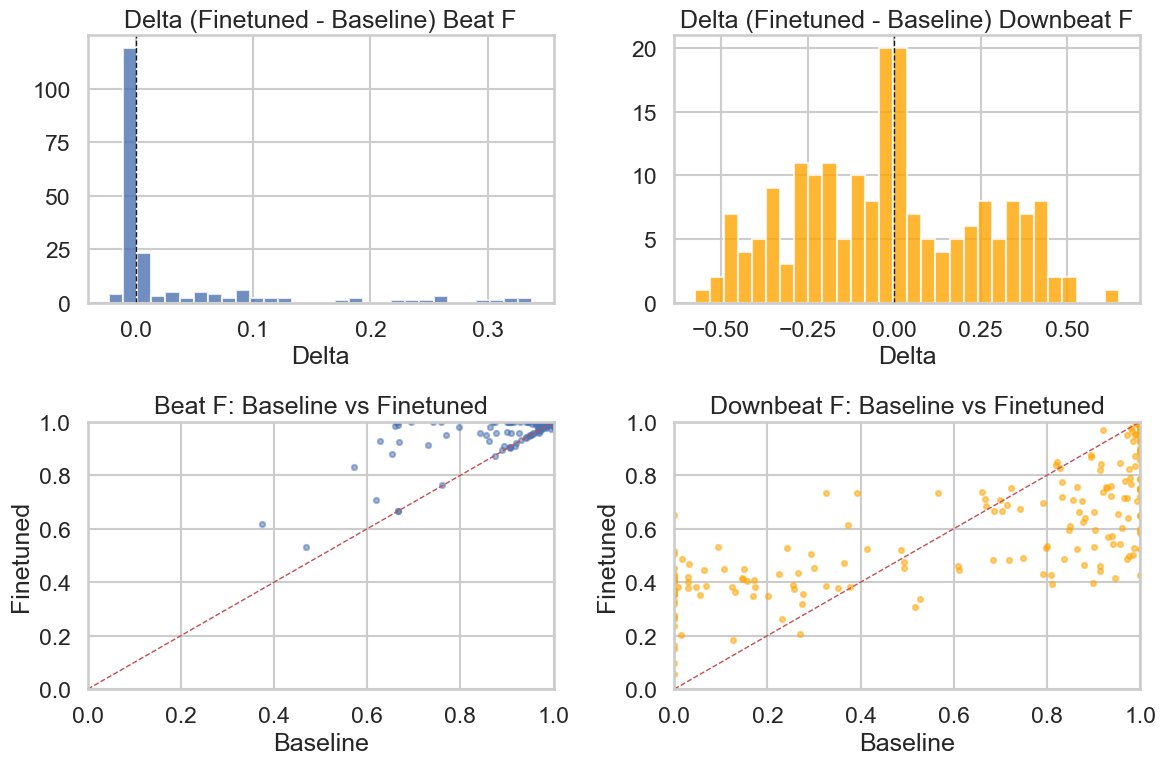

In [32]:
# Useful plots: delta distributions and FT-vs-baseline scatter
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1) Beat delta histogram
axes[0,0].hist(cmp['delta_ft_minus_bt_beat_F-measure'], bins=30, alpha=0.8)
axes[0,0].axvline(0, color='k', linestyle='--', linewidth=1)
axes[0,0].set_title('Delta (Finetuned - Baseline) Beat F')
axes[0,0].set_xlabel('Delta')

# 2) Downbeat delta histogram
axes[0,1].hist(cmp['delta_ft_minus_bt_downbeat_F-measure'], bins=30, alpha=0.8, color='orange')
axes[0,1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[0,1].set_title('Delta (Finetuned - Baseline) Downbeat F')
axes[0,1].set_xlabel('Delta')

# 3) Beat scatter
axes[1,0].scatter(cmp['bt_beat_F-measure'], cmp['ft_beat_F-measure'], s=14, alpha=0.5)
axes[1,0].plot([0,1],[0,1], 'r--', linewidth=1)
axes[1,0].set_xlim(0,1); axes[1,0].set_ylim(0,1)
axes[1,0].set_title('Beat F: Baseline vs Finetuned')
axes[1,0].set_xlabel('Baseline'); axes[1,0].set_ylabel('Finetuned')

# 4) Downbeat scatter
axes[1,1].scatter(cmp['bt_downbeat_F-measure'], cmp['ft_downbeat_F-measure'], s=14, alpha=0.5, color='orange')
axes[1,1].plot([0,1],[0,1], 'r--', linewidth=1)
axes[1,1].set_xlim(0,1); axes[1,1].set_ylim(0,1)
axes[1,1].set_title('Downbeat F: Baseline vs Finetuned')
axes[1,1].set_xlabel('Baseline'); axes[1,1].set_ylabel('Finetuned')

plt.tight_layout()
fig.savefig(IMG_DIR / 'split_comparison_delta_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 12) Export Tables

Writes analysis-ready CSVs for paper/report figures and appendix tables.

In [33]:
# Optional: save key tables for report writing
out_dir = Path('csvs')
out_dir.mkdir(exist_ok=True)

cmp.to_csv(out_dir / 'split_comparison_track_level.csv', index=False)
summary.to_csv(out_dir / 'split_comparison_summary_means.csv')
print('Wrote:')
print(out_dir / 'split_comparison_track_level.csv')
print(out_dir / 'split_comparison_summary_means.csv')

Wrote:
csvs/split_comparison_track_level.csv
csvs/split_comparison_summary_means.csv


KeyError: "['beat_P-score', 'beat_Information gain'] not in index"

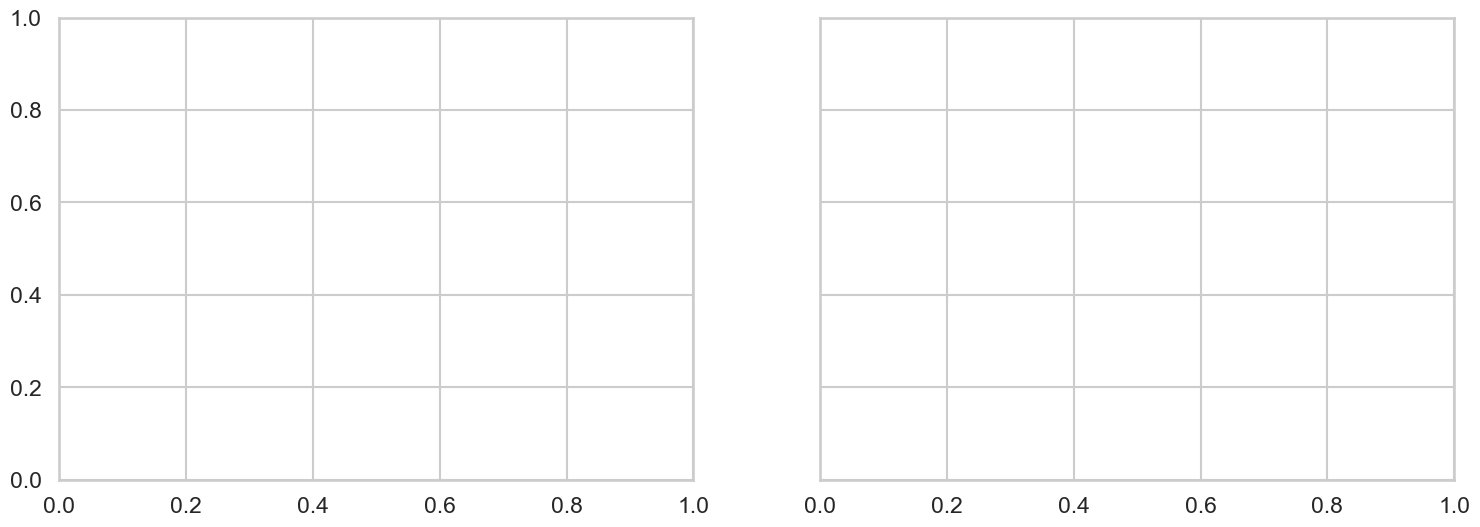

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Expanded metrics and polished layout; keep only metrics present in the loaded CSVs.
candidate_metrics = ['F-measure', 'Cemgil', 'P-score', 'CMLt', 'AMLt', 'Information gain']
model_order = ['Beat This finetuned', 'Beat This baseline', 'madmom']
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for i, prefix in enumerate(['beat', 'downbeat']):
    available = [m for m in candidate_metrics if f'{prefix}_{m}' in summary.columns]
    cols = [f'{prefix}_{m}' for m in available]
    plot_df = summary.loc[model_order, cols].copy()
    plot_df.columns = available

    x = np.arange(len(available))
    width = 0.24

    for j, model in enumerate(model_order):
        vals = plot_df.loc[model].values
        axes[i].bar(
            x + (j - 1) * width,
            vals,
            width=width,
            label=model,
            color=model_colors[j],
            edgecolor='black',
            linewidth=0.6,
            alpha=0.95,
        )

        # annotate F-measure above corresponding bars
        f_measure_idx = available.index('F-measure')
        f_measure_val = vals[f_measure_idx]
        f_measure_x = x[f_measure_idx] + (j - 1) * width
        axes[i].text(
            f_measure_x,
            f_measure_val + 0.015,
            f"{f_measure_val:.3f}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
        )

    axes[i].set_title(f"{prefix.capitalize()} Metrics", fontsize=16, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(available, rotation=20, ha='right')
    axes[i].set_ylim(0, 1.02)
    axes[i].set_ylabel('Score')
    axes[i].grid(axis='y', alpha=0.25)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# move legend above plots to avoid overlap
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.05))

fig.suptitle("Split-Test Comparison Across Models", fontsize=18, fontweight='bold', y=1.12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(IMG_DIR / 'split_comparison_metric_bars.png', dpi=300, bbox_inches='tight')
plt.show()